In [2]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/ADME_ML


In [3]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
# import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle
import json

from pathlib import Path
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
# import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold
from sklearn import metrics as _m
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
# from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
## load internal (in-house) + public-augmented data, champion model, eval helpers
from copy import deepcopy
from itertools import combinations


# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
# from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from python.harmonize_sol import harmonize_solubility

from get_library import get_df   # CDD Vault collection export
from get_protocol_data import get_data, load_config, alias_map
# from tdc.multi_pred import DTI

import yaml
from python.ADME_build_ML import PARAMS, DATA, OUTPUT   # CLI classes reused here (%autoreload picks up edits)
from IPython.display import HTML, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# FUNCTIONS

In [4]:
# per-endpoint classification sign (favorable/positive class) + modelling-space transform used on the raw cutoff
_EP_SIGN = {'solubility': '>=', 'logd': '<', 'hlm': '<', 'mlm': '<', 'rlm': '<', 'caco2': '>=', 'mdck': '>=', 'ppb': '<'}
_EP_TF   = {'solubility': 'log10', 'logd': 'identity', 'hlm': 'log10', 'mlm': 'log10', 'rlm': 'log10', 'caco2': 'log10', 'mdck': 'log10', 'ppb': 'logit_pct'}
# regression columns: table label -> key in each <exp>_metrics dict (from ML_Reg.get_reg_metrics_from_preddf)
_REG_COLS = {'R2_det': 'r2det', 'R2_pears': 'r2', 'RMSE': 'rmse', 'N': 'n_test', 'n_train': 'n_train'}
_CLS_COLS = ['Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC']
_COLS = list(_REG_COLS) + _CLS_COLS
_HIGHER = {'R2_det', 'R2_pears', 'Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC'}; _LOWER = {'RMSE'}   # N / n_train unscored

def _to_model(raw, tf):   # raw-unit cutoff -> modelling space (pred_df is in modelling space)
    if tf == 'log10':     return np.log10(raw)
    if tf == 'logit_pct': return np.log10(raw / (100.0 - raw))
    return raw

def _classif_metrics(pdf, ctf, sign):   # binary triage metrics from a pred_df at the cutoff
    d = pdf.dropna(subset=['real_y', 'pred_y']); yo = d['real_y'].to_numpy(float); yp = d['pred_y'].to_numpy(float)
    rc, pc = (yo < ctf, yp < ctf) if sign == '<' else (yo >= ctf, yp >= ctf)
    return {'Accuracy': _m.accuracy_score(rc, pc), 'PPV': _m.precision_score(rc, pc, zero_division=0),
            'NPV': _m.precision_score(~rc, ~pc, zero_division=0), 'F1(+)': _m.f1_score(rc, pc, zero_division=0),
            'F1(-)': _m.f1_score(rc, pc, pos_label=False, zero_division=0),
            'MCC': _m.matthews_corrcoef(rc, pc) if (rc.min() != rc.max() and pc.min() != pc.max()) else np.nan}

def endpoint_metrics_table_from_dict(metrics_dict, endpoint):
    """HTML table for one endpoint: <exp>_metrics (regression) + <exp>_preddf (classification @ CUTOFFS[endpoint]).

    One row per experiment (the *_preddf entries are used, not shown as rows). CV rows first, temporal rows
    (key contains 'temp') after a double rule. Best per column = bold cyan, worst = orange, WITHIN each
    category. Returns the numeric DataFrame.
    """
    # cutoff in modelling space + favorable-class sign for this endpoint
    ctf = _to_model(CUTOFFS[endpoint], _EP_TF[endpoint]); sign = _EP_SIGN[endpoint]
    # one row per experiment: regression from <exp>_metrics, classification from <exp>_preddf
    exps = [k[:-len('_metrics')] for k in metrics_dict if k.endswith('_metrics')]
    rows = {}
    for e in exps:
        reg = metrics_dict.get(e + '_metrics', {})
        row = {col: reg.get(src) for col, src in _REG_COLS.items()}
        pdf = metrics_dict.get(e + '_preddf')
        if pdf is not None:
            row.update(_classif_metrics(pdf, ctf, sign))
        rows[e] = row
    df = pd.DataFrame(rows).T.reindex(columns=_COLS).apply(pd.to_numeric, errors='coerce')
    # category: CV (0) vs temporal (1); sort category first, then R2det descending within
    df['_ci'] = [1 if 'temp' in k.lower() else 0 for k in df.index]
    df = df.sort_values(['_ci', 'R2_det'], ascending=[True, False]); ci = df['_ci'].to_numpy()
    # best/worst per scored column, WITHIN each category
    def _bw(sub):
        b, w = {}, {}
        for c in _COLS:
            if c in _HIGHER:  b[c], w[c] = sub[c].max(), sub[c].min()
            elif c in _LOWER: b[c], w[c] = sub[c].min(), sub[c].max()
        return b, w
    bws = {c: _bw(df[df['_ci'] == c]) for c in set(ci)}
    CY, OR = '#0097A7', '#F57C00'
    def _fmt(c, v):
        if c in ('N', 'n_train'): return 'nan' if pd.isna(v) else f'{int(v)}'
        return 'nan' if pd.isna(v) else f'{v:.3g}'
    def _td(c, v, bw, sep=''):
        best, worst = bw; s = _fmt(c, v); base = f'text-align:right;padding:2px 8px{sep}'
        if c in best and not pd.isna(v):
            if v == best[c]:                          return f'<td style="color:{CY};font-weight:700;{base}">{s}</td>'
            if v == worst[c] and worst[c] != best[c]: return f'<td style="color:{OR};{base}">{s}</td>'
        return f'<td style="{base}">{s}</td>'
    # header + body (double rule between CV and temporal)
    th = ''.join(f'<th style="text-align:right;padding:2px 8px;border-bottom:1px solid #999">{c}</th>' for c in _COLS)
    body = ''
    for i, (k, r) in enumerate(df.iterrows()):
        sep = ';border-top:3px double #666' if (i > 0 and ci[i] != ci[i - 1]) else ''
        body += (f'<tr><td style="text-align:left;font-weight:600;padding:2px 8px{sep}">{k}</td>' +
                 ''.join(_td(c, r[c], bws[ci[i]], sep) for c in _COLS) + '</tr>')
    cap = (f'<b>{endpoint}</b> — regression + classification @ cutoff {CUTOFFS[endpoint]:g} (sign {sign}) · '
           f'<span style="color:{CY};font-weight:700">best</span>/<span style="color:{OR}">worst</span> per column, '
           f'within each category (double rule = CV / temporal boundary)')
    display(HTML(f'<div style="font:13px sans-serif"><p>{cap}</p><table style="border-collapse:collapse">'
                 f'<thead><tr><th style="text-align:left;padding:2px 8px;border-bottom:1px solid #999">pred_df</th>{th}</tr></thead>'
                 f'<tbody>{body}</tbody></table></div>'))
    return df[_COLS]


def make_model(use_cuml=False, n_bins=32):
    """Champion RF: sklearn (default) or RAPIDS cuRF on GPU (use_cuml=True; needs the `rapids` kernel, no uq_std/confidence).
    n_bins is the cuRF speed knob (fewer split candidates -> faster; default 32 vs cuML's 128). NOTE: cuRF is slow at
    the full ~4469-feature width regardless of n_bins; reduce features for a real speedup (see README)."""
    if use_cuml:
        from cuml.ensemble import RandomForestRegressor as cuRF
        return cuRF(**cfg['champion'], n_bins=n_bins, n_streams=4, random_state=cfg['seed'])   # cuML has no n_jobs
    return RandomForestRegressor(**cfg['champion'], n_jobs=cfg['n_jobs'], random_state=cfg['seed'])


def transfer(combo, use_cuml=False):
    tr = pub.compound[pub.origin.isin(combo)].tolist()
    _, pr = ML_Reg.K_fold_by_defined_IDs(d, 'compound', [[tr, internal.compound.tolist()]], model=make_model(use_cuml),
                                         col_to_rm=['compound', 'smiles', 'label', 'source', 'origin', '_ik'], v=False)
    y, p = pr.real_y.values, pr.pred_y.values
    return {'combo': '+'.join(o.split(':')[-1] for o in combo), 'n_train': len(tr),
            'R2_pears': np.corrcoef(y, p)[0, 1] ** 2, 'R2_det': 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum(),
            'RMSE': (((y - p) ** 2).mean()) ** 0.5}

def predict_and_record(d, result_df, exp_name='default', ids=None, col_to_rm=None, model=None, use_cuml=False):
    mdl = make_model(True) if use_cuml else (model if model is not None else make_model(False))   # per-run backend choice
    _ , result_df[exp_name + '_preddf'] = ML_Reg.K_fold_by_defined_IDs(d, 'compound', ids, model=mdl, col_to_rm=col_to_rm, v=False, uq=True)
    result_df[exp_name + '_metrics'] = ML_Reg.get_reg_metrics_from_preddf(result_df[exp_name + '_preddf'], ntrain=d.shape[0])

    # assign absolute residual + confidence from the RF tree-variance uncertainty
    result_df[exp_name + '_preddf']['residuals'] = abs(result_df[exp_name + '_preddf']['pred_y'] - result_df[exp_name + '_preddf']['real_y'])
    result_df[exp_name + '_preddf'] = ML_Reg.uq_std_to_confidence(result_df[exp_name + '_preddf'])

    return result_df

# MAIN

In [5]:
## params — every YAML key becomes an attribute (params.ADME_ENDPOINTS); see python/ADME_build_ML.py:PARAMS
CONFIG = 'config/config.yaml'
params = PARAMS(CONFIG)
params.load_params()
## transition shim — keep the bare YAML names (ADME_ENDPOINTS, CUTOFFS, SERAC_C, RF_SINGLETASK, ...) working below
globals().update({k: v for k, v in params.__dict__.items() if k.isupper()})
config = params

> loaded 17 params from config/config.yaml


In [6]:
CUTOFFS = {  # raw units; sign in comment. Conventions, not hard rules — see caveats
  'solubility': 10,    # µM,        >= soluble
  'logd':       3,     # logD7.4,   <= within sweet-spot upper bound (>3 = too lipophilic)
  'caco2':      10,    # 1e-6 cm/s, >= high permeability (fa~0.8-0.9)
  'mdck':       10,    # 1e-6 cm/s, >= high permeability
  'ppb':        1,     # % unbound, <= 1  => highly bound (fu<=0.01)
  'hlm':        12,    # µL/min/mg, < 12  => low clearance/stable  (WEAK: measurement floor, no verified triage cutoff)
  'mlm':        12,    # µL/min/mg, same caveat (mouse)
  'rlm':        12,    # µL/min/mg, same caveat (rat)
}

## model params
cfg = yaml.safe_load(open('config/config.yaml'))['RF_SINGLETASK']
# champion RF (sklearn); per-run cuRF is opt-in via use_cuml=True on transfer() / predict_and_record()
model = RandomForestRegressor(**cfg['champion'], n_jobs=cfg['n_jobs'], random_state=cfg['seed'])

## 0. Imports and data formatting

In [7]:
metrics_results = {} # to hold of the predictive results
output          = OUTPUT(params) #_> output.cfg (RF_SINGLETASK), output.model (champion RF), output.metrics_results {}, output.res_origin_powerset

## data — internal experimental CDD pull (see python/ADME_build_ML.py:DATA); overwrite=True re-pulls from CDD Vault + re-caches
data = DATA()
data.load_df_internal_exp_all(params) #_> data.df_internal_exp_all (raw CDD pull: 1 row/compound, every endpoint col) + data.params
data.load_combine_dfs(params)         #_> data.dfs[<ep>] (per-endpoint long: compound/smiles/label/source/origin) + data.df_all (WIDE: 1 row/compound x 8 endpoint label cols, modelling space)
data.build_MF_features(params, type='H237', date='20260824') #_> data.MF_features['all'] (compound + 4469 H237 features, incl. the 200 DS_ cols) -> output/features/<date>_MF_features.parquet

> df_internal_exp_all: 326 compounds x 102 columns
> solubility augmented: 17998 rows (internal=121, EXP=17877)
> logd augmented: 4518 rows (internal=318, EXP=4200)


> hlm augmented: 278152 rows (internal=325, EXP=277827)
> mlm augmented: 273963 rows (internal=325, EXP=273638)
> rlm augmented: 276731 rows (internal=39, EXP=276692)
> caco2 augmented: 337779 rows (internal=95, EXP=337684)


/home/gtamo/miniconda3/envs/chemprop/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


> mdck augmented: 273747 rows (internal=109, EXP=273638)
> ppb augmented: 275515 rows (internal=69, EXP=275446)
> df_all: 369138 compounds x 12 cols (8 endpoints; 369138 with >=1 label)


H237 descriptors: 100%|██████████| 128/128 [00:01<00:00, 67.65it/s]


> MF features (H237) [all]: 369138 compounds x 4469 features (public 368812 cached | internal 326 recomputed)


## 1. Compute RF performance metrics for all endpoints

In [8]:
endpoints = ['solubility','logd','hlm','mlm','rlm','caco2','mdck','ppb']
for k in endpoints:
    data.build_ML_data_RF(params, k=k)
    assert stats_tools.check_ML_data(data.ML_data[k], extra_meta_cols=('source', 'origin'),verbose=False)
    data.get_internal_public_sets(k, min_n=1000)
    data.select_best_combo_and_update(params, k)   # combo = BEST_PUBLIC[k] origins present in data.origins

    METRICS_PKL = os.path.join(params.METRICS_PKL_RF_DIR, k + '.pkl')
    output.assess_predictions(data, METRICS_PKL)   # compute-or-load the 6 arms -> output.metrics_results[k]

> ML_data['solubility']: 17997 rows x 4474 cols (cap 15000 raw)


InChIKey: 100%|██████████| 9/9 [00:00<00:00, 11.69it/s]


> solubility: internal=120, public=17877 (origins > 1000: ['thermodynamic:PharmaBench', 'thermodynamic:ChEMBL', 'thermodynamic:Biogen-Fang', 'thermodynamic:AQUA'])
> loaded metrics_results['solubility'] <- output/results/20260825_metrics/solubility.pkl
> ML_data['logd']: 4516 rows x 4474 cols


InChIKey: 100%|██████████| 3/3 [00:00<00:00,  3.95it/s]


> logd: internal=317, public=4199 (origins > 1000: ['TDC:Lipophilicity_AstraZeneca'])
> loaded metrics_results['logd'] <- output/results/20260825_metrics/logd.pkl
> ML_data['hlm']: 277940 rows x 4474 cols


...

> caco2: internal=95, public=331586 (origins > 1000: ['Novartis-NIBR', 'ADMETlab-PROTAC'])
> loaded metrics_results['caco2'] <- output/results/20260825_metrics/caco2.pkl
> ML_data['mdck']: 273731 rows x 4474 cols


InChIKey: 100%|██████████| 137/137 [00:03<00:00, 40.45it/s]


> mdck: internal=107, public=273624 (origins > 1000: ['Novartis-NIBR'])
> loaded metrics_results['mdck'] <- output/results/20260825_metrics/mdck.pkl
> ML_data['ppb']: 275327 rows x 4474 cols


InChIKey: 100%|██████████| 138/138 [00:03<00:00, 40.43it/s]


> ppb: internal=69, public=275258 (origins > 1000: ['Novartis-NIBR', 'TDC:PPBR_AZ'])
> loaded metrics_results['ppb'] <- output/results/20260825_metrics/ppb.pkl


In [9]:
# _ = endpoint_metrics_table_from_dict(output.metrics_results[k], k)

## 2. Individual visualization of RF analysis results

In [10]:
k        = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb'][0]
data.build_ML_data_RF(params, k=k)
assert stats_tools.check_ML_data(data.ML_data[k], extra_meta_cols=('source', 'origin'),verbose=False)
data.get_internal_public_sets(k, min_n=1000)
data.select_best_combo_and_update(params, k)   # combo = BEST_PUBLIC[k] origins present in data.origins

METRICS_PKL = os.path.join(params.METRICS_PKL_RF_DIR, k + '.pkl')
# METRICS_PKL = 'output/results/tmp/'+k+'.pkl'
output.assess_predictions(data, METRICS_PKL)   # compute-or-load the 6 arms -> output.metrics_results[k]
_ = endpoint_metrics_table_from_dict(output.metrics_results[k], k)

> ML_data['solubility']: 17997 rows x 4474 cols (cap 15000 raw)


InChIKey: 100%|██████████| 9/9 [00:00<00:00, 13.67it/s]

> solubility: internal=120, public=17877 (origins > 1000: ['thermodynamic:PharmaBench', 'thermodynamic:ChEMBL', 'thermodynamic:Biogen-Fang', 'thermodynamic:AQUA'])
> loaded metrics_results['solubility'] <- output/results/20260825_metrics/solubility.pkl


pred_df,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
augmented_cv,0.731,0.738,0.615,120,17997,0.85,0.708,0.944,0.791,0.883,0.687
internal_cv,0.678,0.68,0.672,120,120,0.85,0.738,0.91,0.775,0.887,0.665
ext_->_internal,0.419,0.574,0.903,120,17997,0.583,0.425,0.9,0.576,0.59,0.329
augmented_temp,-1.01,0.076,0.594,36,17997,0.778,0.167,0.9,0.2,0.871,0.0791
internal_temp,-2.44,0.008,0.778,36,17997,0.722,0.125,0.893,0.167,0.833,0.0236
ext_->_temp,-2.82,0.002,0.819,36,17997,0.639,0.2,0.952,0.316,0.755,0.239


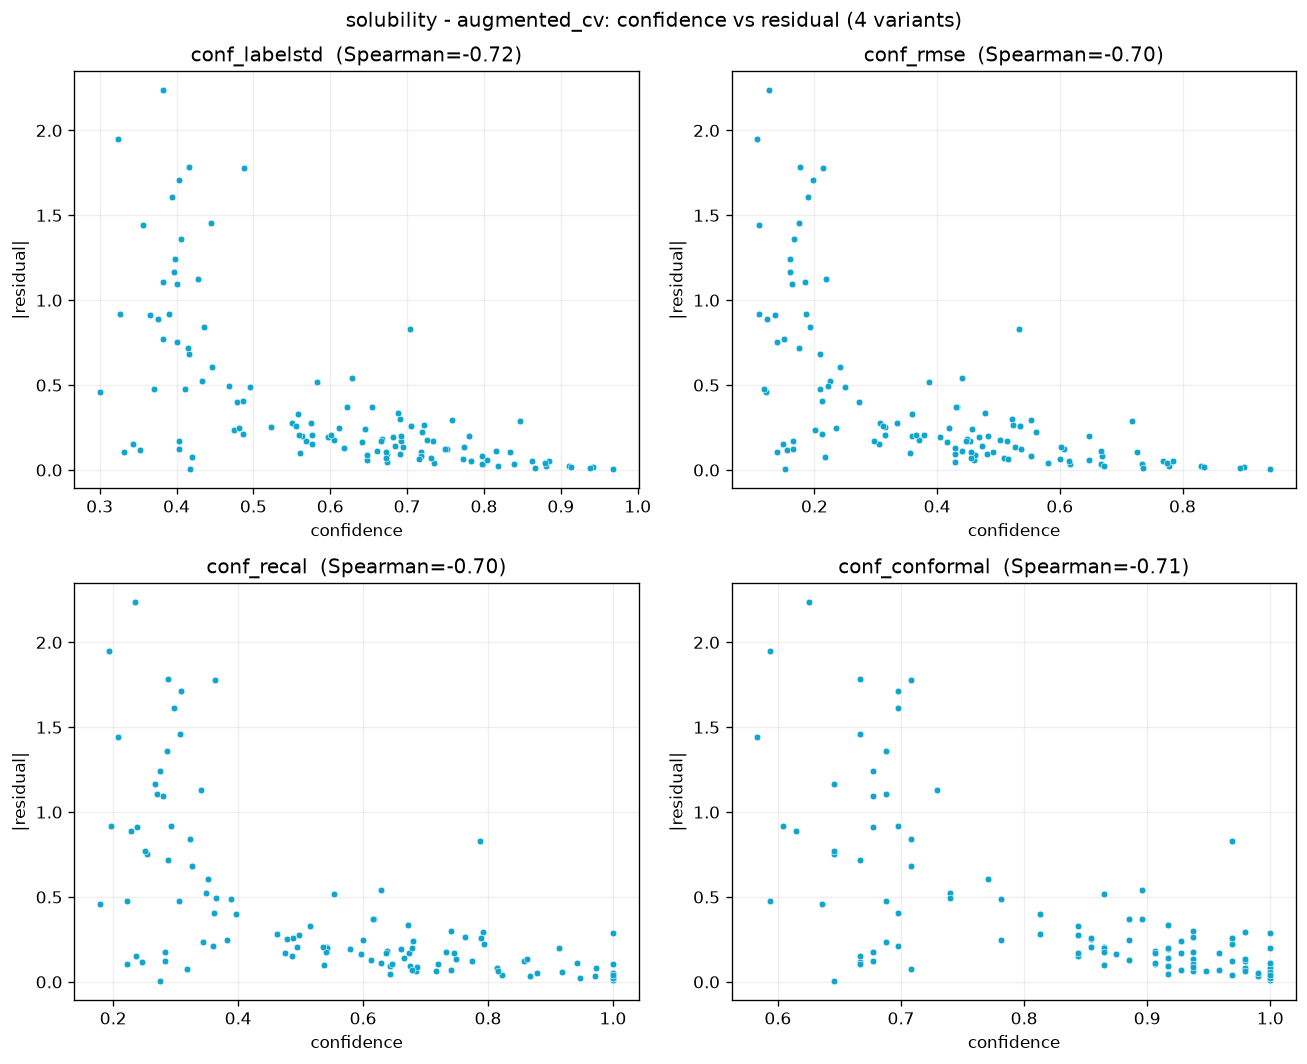

In [11]:
## compare the 4 confidence variants: each conf_* vs |residual| (good = high confidence -> low error)
to_plot   = 'augmented_cv' # 'internal_cv' # 'ext_->_internal' #       'augmented_temp' #   
pdf       = output.metrics_results[k][to_plot+'_preddf']
conf_cols = ['conf_labelstd', 'conf_rmse', 'conf_recal', 'conf_conformal']
fig, axes = plt.subplots(2, 2, figsize=(11, 9), dpi=120)
for ax, cc in zip(axes.ravel(), conf_cols):
    rho = pdf[cc].corr(pdf['residuals'], method='spearman')   # negative -> higher confidence tracks lower error
    sns.scatterplot(x=cc, y='residuals', data=pdf, color=SERAC_C['azure'], s=16, alpha=1.0, ax=ax)
    ax.set_title(f'{cc}  (Spearman={rho:.2f})'); ax.set_xlabel('confidence'); ax.set_ylabel('|residual|')
    ax.grid(alpha=0.2); ax.set_axisbelow(True)   # grey grid behind points, like plot_parity_from_pred_df
fig.suptitle(f'{k} - {to_plot}: confidence vs residual (4 variants)')
plt.tight_layout(); plt.show()

> parity: n=120
  value: R²pears=0.738 R²det=0.731 RMSE=0.615
> parity: n=71
  value: R²pears=0.972 R²det=0.964 RMSE=0.210


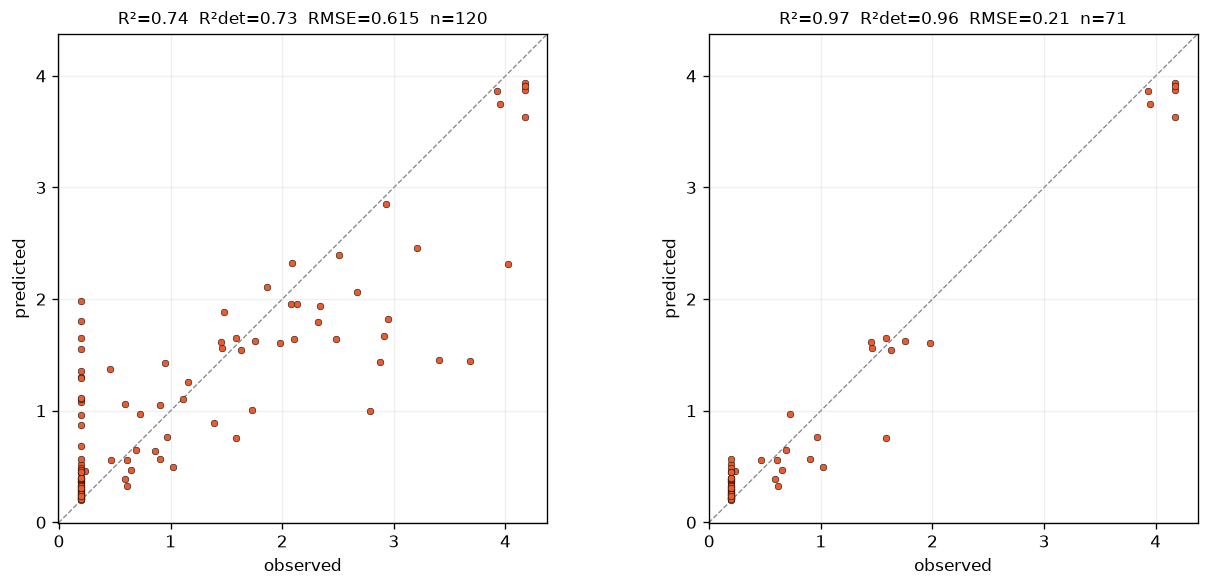

In [12]:
sel_conf   = 'conf_recal' # 'conf_rmse' # 
sel_ctf    = 0.5
sel_preddf = output.metrics_results[k][to_plot+'_preddf'].copy()
sel_preddf = sel_preddf[sel_preddf[sel_conf]>=sel_ctf]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=120)
## left: all points; right: confidence-filtered, forced to the SAME x/y limits (lims from the left plot)
res_all = ML_Reg.plot_parity_from_pred_df(output.metrics_results[k][to_plot+'_preddf'], color=SERAC_C['ember'], ax=ax1)
_       = ML_Reg.plot_parity_from_pred_df(sel_preddf, color=SERAC_C['ember'], ax=ax2, lims=res_all['lims'])
plt.tight_layout(); plt.show()

> parity: n=120
  log10: R²pears=0.738 R²det=0.731 RMSE=0.615
  raw uM: R²pears=0.809 R²det=0.629 RMSE=1851
> parity: n=71
  log10: R²pears=0.972 R²det=0.964 RMSE=0.210
  raw uM: R²pears=0.917 R²det=0.720 RMSE=1951


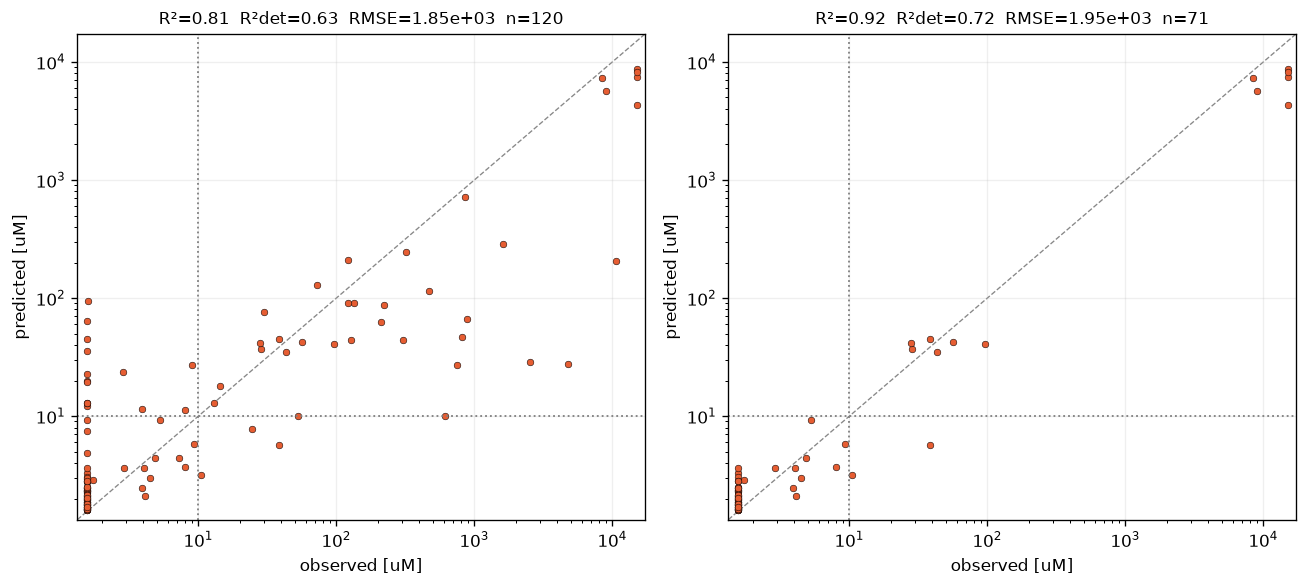

In [ ]:
## Transformed units!!
sel_conf   = 'conf_recal' # 'conf_rmse' #
sel_ctf    = 0.5
sel_preddf = output.metrics_results[k][to_plot+'_preddf'].copy()
sel_preddf = sel_preddf[sel_preddf[sel_conf] >= sel_ctf]

# raw-unit plotting: back-transform + axis label + triage cross all come from config
_pu_tf   = params.ADME_ENDPOINTS[k]['transform']          # log10 | identity | logit_pct
_pu_unit = params.ADME_ENDPOINTS[k].get('unit')           # uM | logD7.4 | uL/min/mg | 1e-6cm/s | pct_unbound
_pu_ab   = params.webapp['cutoffs'][k]['value']           # raw-unit triage cutoff (10 uM, 12 uL/min/mg, ...)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=120)
## left: all points; right: confidence-filtered, forced to the SAME x/y limits (lims from the left plot)
res_all = ML_Reg.plot_parity_from_pred_df(output.metrics_results[k][to_plot+'_preddf'],
                                          transform=_pu_tf, unit=_pu_unit, abline=_pu_ab,
                                          color=SERAC_C['ember'], ax=ax1)
_       = ML_Reg.plot_parity_from_pred_df(sel_preddf,
                                          transform=_pu_tf, unit=_pu_unit, abline=_pu_ab,
                                          color=SERAC_C['ember'], ax=ax2, lims=res_all['lims'])
plt.tight_layout(); plt.show()

<div style="background:#ffffff; color:#000000; padding:14px 18px; border-radius:6px; display:inline-block">

$$\hat\sigma_i = \max(a + b\,s_i,\, 0)
\qquad
\texttt{conf\_recal}_i = \exp\!\left(-\frac{\hat\sigma_i}{\text{rmse}_{\text{cv}}}\right)$$

</div>

In [ ]:
## run combinatorial analysis ## sol
# output.run_origin_powerset(data)   # scores every public-origin subset via data.transfer
# display(output.res_origin_powerset.round(3))

## 3. Visualize all results

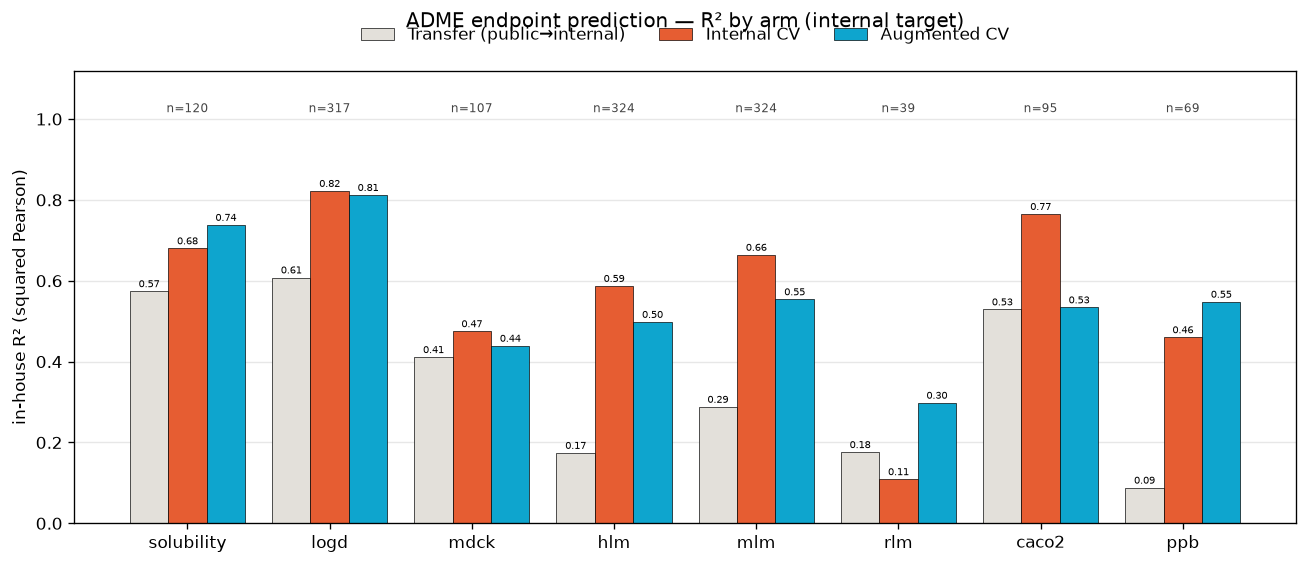

In [13]:
## visualize transfer, internal cv and augmented cv:
ks = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb']

## choose the metric: 'r2' = squared Pearson (affine-invariant) | 'r2det' = coefficient of determination (calibration-sensitive)
METRIC = 'r2'
_ML = {'r2': 'in-house R² (squared Pearson)', 'r2det': 'in-house R²det (coefficient of determination)'}
_MT = {'r2': 'R²', 'r2det': 'R²det'}

## three arms to compare: (arm key in metrics_results, legend label, SERAC color)
arms = [('ext_->_internal', 'Transfer (public→internal)', SERAC_C['paper']),
        ('internal_cv',      'Internal CV',                SERAC_C['ember']),
        ('augmented_cv',     'Augmented CV',               SERAC_C['azure'])]

## chosen metric per endpoint x arm + the internal test size (same across arms)
r2 = {a: [output.metrics_results[k].get(a + '_metrics', {}).get(METRIC, np.nan) for k in ks] for a, _, _ in arms}
ns = [output.metrics_results[k].get('internal_cv_metrics', {}).get('n_test', 0) for k in ks]

## R2det can be strongly negative (uncalibrated arms) -> adaptive limits; R2 keeps the fixed 0-1.12 frame
_vals = [v for a in r2 for v in r2[a] if np.isfinite(v)]
if METRIC == 'r2':
    _lo, _hi, _ny = 0.0, 1.12, 1.01
else:
    _vmin, _vmax = min(_vals), max(_vals); _pad = 0.14 * (_vmax - _vmin)
    _lo, _hi = min(0.0, _vmin) - 0.4 * _pad, _vmax + 1.6 * _pad
    _ny = _vmax + 0.35 * _pad

x = np.arange(len(ks)); w = 0.27
fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)
## one value-labeled bar group per arm
for i, (a, label, color) in enumerate(arms):
    bars = ax.bar(x + (i - 1) * w, r2[a], w, label=label, color=color, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)
## zero reference line whenever bars go below it
if _lo < 0:
    ax.axhline(0, color='#444', lw=0.8, zorder=1)
## internal test size on top of each endpoint
for xi, n in zip(x, ns):
    ax.text(xi, _ny, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.set_ylabel(_ML[METRIC]); ax.set_ylim(_lo, _hi)
ax.set_title(f'ADME endpoint prediction — {_MT[METRIC]} by arm (internal target)', pad=26)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()



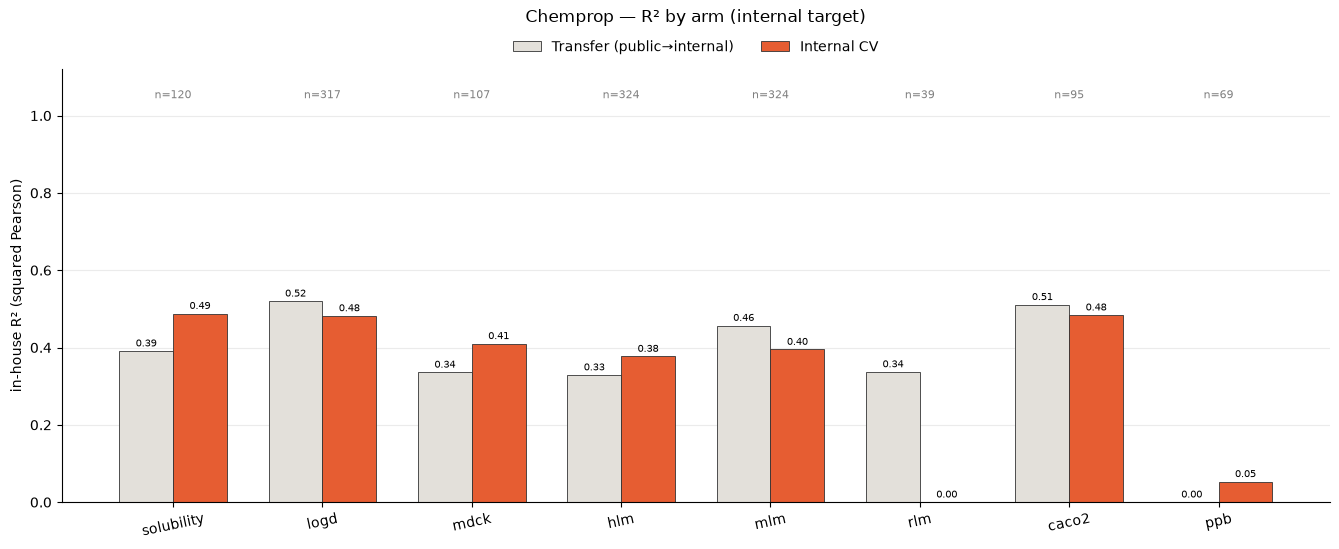

endpoint    pub_r2  int_r2   pub_R2det  int_R2det  grouping
solubility   0.391   0.488      -0.114      0.484  all8
logd         0.520   0.482       0.478      0.471  sol_lipo
mdck         0.336   0.410      -1.456      0.383  mdck_perm
hlm          0.329   0.377      -0.845      0.320  clearance
mlm          0.457   0.395      -0.188      0.357  clearance
rlm          0.337   0.000      -0.302     -0.162  clearance
caco2        0.511   0.484       0.241      0.479  permeability
ppb          0.000   0.053      -3.353      0.050  ppb_fu


In [14]:
## Chemprop transfer and internal cv:
## Chemprop transfer and internal cv:
# chemprop only: public->internal (pretrain_only, no folds) vs internal-only CV (scratch, RF's folds)
EPS = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb']

# best grouping per endpoint for each chemprop arm (pretrain_only was run with --grouping best)
_cx = {}
for _cx_row in pd.read_csv('output/predictions_runs_chemprop_transfer/summary_transfer.csv').itertuples():
    _cx.setdefault(_cx_row.endpoint, {})
    _cx_prev = _cx[_cx_row.endpoint].get(_cx_row.arm)
    if _cx_prev is None or _cx_row.r2det > _cx_prev['r2det']:
        _cx[_cx_row.endpoint][_cx_row.arm] = {'r2': _cx_row.r2, 'r2det': _cx_row.r2det,
                                              'g': _cx_row.grouping, 'n': _cx_row.n}

# the two series, in endpoint order
_cx_pub = [_cx[_e]['pretrain_only']['r2'] for _e in EPS]
_cx_int = [_cx[_e]['scratch']['r2'] for _e in EPS]
_cx_n   = [_cx[_e]['scratch']['n'] for _e in EPS]

# grouped bars, same palette/layout as the all-model figure
_cx_x = np.arange(len(EPS)); _cx_w = 0.36
_cx_fig, _cx_ax = plt.subplots(figsize=(13.5, 5.6))
_cx_b1 = _cx_ax.bar(_cx_x - _cx_w / 2, _cx_pub, _cx_w, label='Transfer (public→internal)',
                    color=SERAC_C['paper'], edgecolor='#333', lw=.6)
_cx_b2 = _cx_ax.bar(_cx_x + _cx_w / 2, _cx_int, _cx_w, label='Internal CV',
                    color=SERAC_C['ember'], edgecolor='#333', lw=.6)

# value labels on every bar
for _cx_bar in (_cx_b1, _cx_b2):
    _cx_ax.bar_label(_cx_bar, fmt='%.2f', fontsize=7.5, padding=1.5)

# per-endpoint n across the top
for _cx_i, _cx_ep in enumerate(EPS):
    _cx_ax.annotate(f"n={_cx_n[_cx_i]}", (_cx_x[_cx_i], 1.045), ha='center', fontsize=8, color='grey')

_cx_ax.set_xticks(_cx_x); _cx_ax.set_xticklabels(EPS, rotation=12)
_cx_ax.set_ylabel('in-house R² (squared Pearson)'); _cx_ax.set_ylim(0, 1.12)
_cx_ax.grid(axis='y', alpha=.25); _cx_ax.set_axisbelow(True)
for _cx_spine in ('top', 'right'):
    _cx_ax.spines[_cx_spine].set_visible(False)

# legend just above the axes, title padded clear of it
_cx_ax.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1.005), frameon=False)
_cx_ax.set_title('Chemprop — R² by arm (internal target)', pad=34, fontsize=12)
_cx_fig.tight_layout(); plt.show()

# grouping behind each bar + the R2det view (Pearson hides the calibration failure)
print('endpoint    pub_r2  int_r2   pub_R2det  int_R2det  grouping')
for _cx_ep in EPS:
    _cx_p, _cx_s = _cx[_cx_ep]['pretrain_only'], _cx[_cx_ep]['scratch']
    print(f"{_cx_ep:11}{_cx_p['r2']:>7.3f}{_cx_s['r2']:>8.3f}{_cx_p['r2det']:>12.3f}{_cx_s['r2det']:>11.3f}  {_cx_p['g']}")

## 4. Compute Chemprop performance metrics for selected endpoints

In [ ]:
endpoints = ['solubility','logd','hlm','mlm','rlm','caco2','mdck','ppb']
for k in endpoints:
    # Build ML data for chemprop 
    data.build_ML_data_CP(params, k=k, leak='exact')   #_> data.cp_pub / cp_int / cp_folds / cp_tasks / cp_ds_cols / cp_grouping / cp_fold_source
    # Run/load to record performance metrics on augmented/internal cv and transfer

    METRICS_PKL_CP = os.path.join(params.METRICS_PKL_CP_DIR, k + '.pkl')
    output.assess_predictions(data, METRICS_PKL_CP, ml_model='chemprop')   # compute-or-load the 3 arms -> output.metrics_results_cp[k]


## 5. Individual visualization of Chemprop results

In [26]:
k = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb'][7]

## chemprop dataset for one endpoint x grouping — the analogue of build_ML_data_<ep>, with the grouping's task columns
## folds come from params.METRICS_PKL_RF_DIR/<k>.pkl (RF's EXACT folds); absent -> an independent split
data.build_ML_data_CP(params, k=k, leak='exact')   #_> data.cp_pub / cp_int / cp_folds / cp_tasks / cp_ds_cols / cp_grouping / cp_fold_source

## chemprop arms for k — pretrain on cp_pub ONCE, then augmented_cv (transfer) / internal_cv (scratch) / ext_->_internal
METRICS_PKL_CP = os.path.join(params.METRICS_PKL_CP_DIR, k + '.pkl')
output.assess_predictions(data, METRICS_PKL_CP, ml_model='chemprop')   # compute-or-load the 3 arms -> output.metrics_results_cp[k]
_ = endpoint_metrics_table_from_dict(output.metrics_results_cp[k], k)

> leak control (exact): dropped 0 of 339923 public rows sharing a molecule with the 69 internal compounds
> cp_folds: RF's EXACT folds from output/results/20260825_metrics/ppb.pkl — chemprop and RF score the identical partitions
> CP_data 'ppb_fu' for 'ppb': tasks=['ppb', 'LogFu_Rat', 'LogFu_Human', 'LogFu_Mouse', 'LogFu_Dog', 'LogFu_Monkey', 'HPLC_LogFu_HSA', 'LogFubrain', 'LogFumic', 'Direct_NIBR_LogP', 'Direct_NIBR_LogD7_4'] | DS_ features=200
  cp_pub   339923 public rows   non-null: {'ppb': 338582, 'LogFu_Rat': 275529, 'LogFu_Human': 275529, 'LogFu_Mouse': 275529, 'LogFu_Dog': 275529, 'LogFu_Monkey': 275529, 'HPLC_LogFu_HSA': 275529, 'LogFubrain': 275529, 'LogFumic': 275529, 'Direct_NIBR_LogP': 275529, 'Direct_NIBR_LogD7_4': 275529}
  cp_int       69 internal rows non-null: {'ppb': 69, 'LogFu_Rat': 0, 'LogFu_Human': 0, 'LogFu_Mouse': 0, 'LogFu_Dog': 0, 'LogFu_Monkey': 0, 'HPLC_LogFu_HSA': 0, 'LogFubrain': 0, 'LogFumic': 0, 'Direct_NIBR_LogP': 0, 'Direct_NIBR_LogD7_4': 0}
  cp_fold

pred_df,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv,0.009,0.061,0.47,69,69,0.609,0.547,0.812,0.682,0.491,0.304
augmented_cv,-0.044,0.021,0.483,69,69,0.536,0.5,0.609,0.59,0.467,0.103
ext_->_internal,-3.35,0,0.985,69,339923,0.551,1,0.544,0.0606,0.705,0.13


> ML_data['ppb']: 332471 rows x 4474 cols


InChIKey:   0%|          | 0/167 [00:00<?, ?it/s][08:43:20] WARNING: not removing hydrogen atom without neighbors
[08:43:20] WARNING: not removing hydrogen atom without neighbors
InChIKey: 100%|██████████| 167/167 [00:04<00:00, 35.36it/s]


> ppb: internal=69, public=332402 (origins > 1000: ['Novartis-NIBR', 'ADMETlab-PROTAC', 'TDC:PPBR_AZ'])
> loaded metrics_results['ppb'] <- output/results/20260825_metrics/ppb.pkl


pred_df,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
augmented_cv,0.537,0.548,0.321,69,332471,0.783,0.774,0.789,0.762,0.8,0.562
internal_cv,0.435,0.46,0.355,69,69,0.797,0.781,0.811,0.781,0.811,0.592
ext_->_internal,-0.944,0.088,0.658,69,332471,0.536,0,0.536,0,0.698,nan
augmented_temp,-0.283,0.279,0.532,21,332471,0.429,0.667,0.389,0.25,0.538,0.04
internal_temp,-0.476,0.064,0.571,21,332471,0.571,0.75,0.462,0.571,0.571,0.212
ext_->_temp,-2.16,0,0.836,21,332471,0.381,0,0.381,0,0.552,nan


ppb: n=69 | RF conf_recal vs |residual| — rf: rho=-0.130 (p=2.9e-01)  cp: rho=-0.162 (p=1.8e-01)
   conf_recal  resid_rf  resid_cp
q                                
0       0.359     0.343     0.517
1       0.435     0.234     0.460
2       0.459     0.232     0.289
3       0.485     0.165     0.154
4       0.534     0.285     0.458


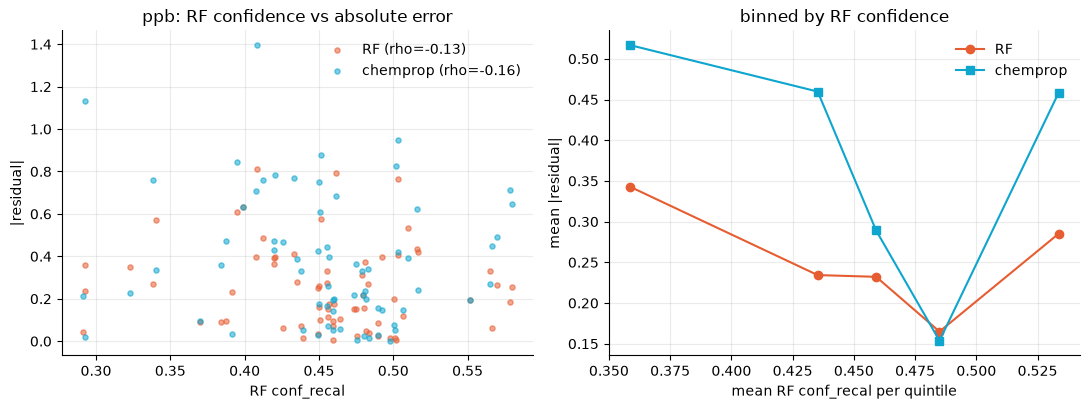

In [27]:
## plot confidence of RF vs residuals of chemprop
data.build_ML_data_RF(params, k=k)
assert stats_tools.check_ML_data(data.ML_data[k], extra_meta_cols=('source', 'origin'),verbose=False)
data.get_internal_public_sets(k, min_n=1000)
data.select_best_combo_and_update(params, k)   # combo = BEST_PUBLIC[k] origins present in data.origins

METRICS_PKL = os.path.join(params.METRICS_PKL_RF_DIR, k + '.pkl')
# METRICS_PKL = 'output/results/tmp/'+k+'.pkl'
output.assess_predictions(data, METRICS_PKL)   # compute-or-load the 6 arms -> output.metrics_results[k]
_ = endpoint_metrics_table_from_dict(output.metrics_results[k], k)

## RF's calibrated confidence carried onto the chemprop predictions — same folds, same compounds
_cf_rf = output.metrics_results[k]['augmented_cv_preddf'][['compound', 'conf_recal', 'residuals']]
_cf_cp = output.metrics_results_cp[k]['augmented_cv_preddf']
_cf_cp['conf_recal_rf'] = _cf_cp.compound.map(dict(zip(_cf_rf.compound, _cf_rf.conf_recal)))

# one row per internal compound, holding RF's confidence and BOTH models' absolute error
_cf = _cf_rf.rename(columns={'residuals': 'resid_rf'}).merge(
    _cf_cp[['compound', 'residuals']].rename(columns={'residuals': 'resid_cp'}), on='compound').dropna()

# Spearman of RF confidence against each model's error; negative = more confidence, less error
_cf_sp = {m: stats.spearmanr(_cf.conf_recal, _cf['resid_' + m]) for m in ('rf', 'cp')}
print(f"{k}: n={len(_cf)} | RF conf_recal vs |residual| — "
      + '  '.join(f"{m}: rho={_cf_sp[m].statistic:+.3f} (p={_cf_sp[m].pvalue:.1e})" for m in ('rf', 'cp')))

# mean error per confidence quintile — the practical read of the same question
_cf_q = _cf.assign(q=pd.qcut(_cf.conf_recal, 5, labels=False, duplicates='drop')).groupby('q')[
    ['conf_recal', 'resid_rf', 'resid_cp']].mean()
print(_cf_q.round(3).to_string())

_cf_fig, _cf_ax = plt.subplots(1, 2, figsize=(11, 4.2))
# left: one point per compound, both models against the same x
for _cf_m, _cf_c, _cf_n in (('rf', SERAC_C['ember'], 'RF'), ('cp', SERAC_C['azure'], 'chemprop')):
    _cf_ax[0].scatter(_cf.conf_recal, _cf['resid_' + _cf_m], s=14, alpha=.55, color=_cf_c,
                      label=f"{_cf_n} (rho={_cf_sp[_cf_m].statistic:+.2f})")
_cf_ax[0].set_xlabel('RF conf_recal'); _cf_ax[0].set_ylabel('|residual|')
_cf_ax[0].set_title(f'{k}: RF confidence vs absolute error'); _cf_ax[0].legend(frameon=False)
# right: the quintile means, which show whether the ranking is usable in practice
_cf_ax[1].plot(_cf_q.conf_recal, _cf_q.resid_rf, 'o-', color=SERAC_C['ember'], label='RF')
_cf_ax[1].plot(_cf_q.conf_recal, _cf_q.resid_cp, 's-', color=SERAC_C['azure'], label='chemprop')
_cf_ax[1].set_xlabel('mean RF conf_recal per quintile'); _cf_ax[1].set_ylabel('mean |residual|')
_cf_ax[1].set_title('binned by RF confidence'); _cf_ax[1].legend(frameon=False)
for _cf_a in _cf_ax:
    _cf_a.grid(alpha=.25); _cf_a.set_axisbelow(True)
    for _cf_s in ('top', 'right'):
        _cf_a.spines[_cf_s].set_visible(False)
_cf_fig.tight_layout(); plt.show()

## 6. Visualiza all results Chemprop + RF

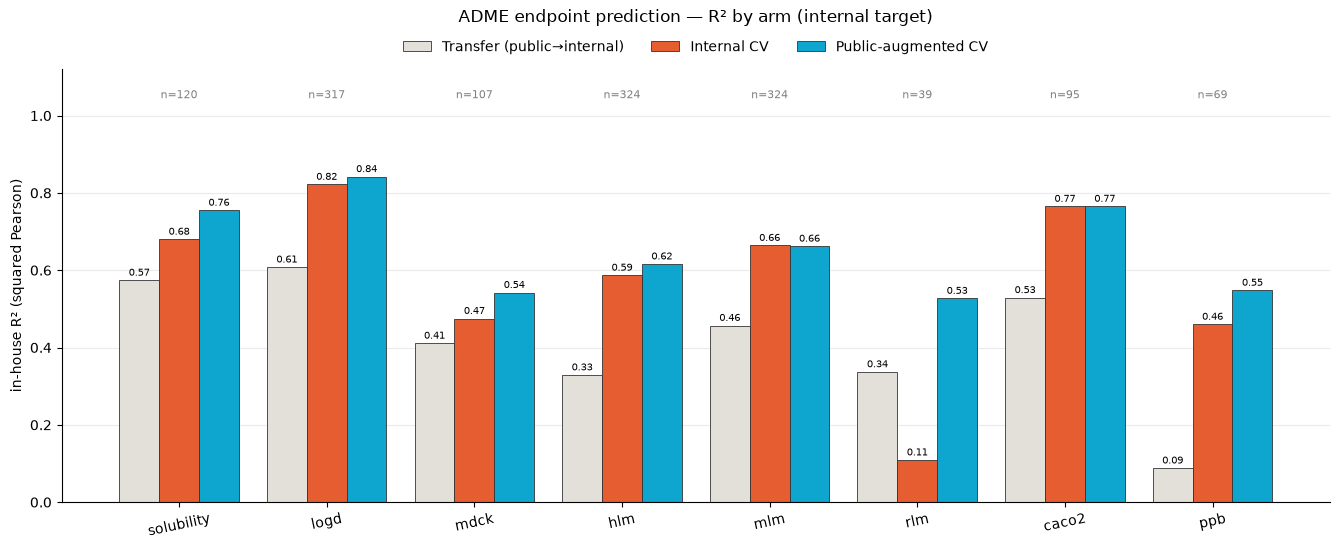

endpoint     transfer  (won by)   internal  (won by)   augmented  (won by)      [r2]
solubility     0.574  RF            0.680  RF             0.755  chemprop (all8)
logd           0.608  RF            0.822  RF             0.842  chemprop (sol_lipo)
mdck           0.411  RF            0.475  RF             0.542  near-shell (dist060_agree)
hlm            0.329  chemprop      0.587  RF             0.616  chemprop (clearance)
mlm            0.457  chemprop      0.664  RF             0.662  chemprop (clearance)
rlm            0.337  chemprop      0.109  RF             0.527  chemprop (clearance)
caco2          0.529  RF            0.765  RF             0.765  near-shell (dist060_agree)
ppb            0.088  RF            0.460  RF             0.548  RF (all public)


In [15]:
## updated figure with chemprop + near-shell
# best-of-public bar per endpoint: RF augmented vs chemprop transfer vs near-shell (RF's folds)
EPS = ['solubility', 'logd', 'mdck', 'hlm', 'mlm', 'rlm', 'caco2', 'ppb']

# choose the metric: 'r2' = squared Pearson (affine-invariant) | 'r2det' = coefficient of determination (calibration-sensitive)
METRIC = 'r2'
CLIP0  = True          # floor negative R2det bars at 0 for readability; labels still show the TRUE value (prefixed ↓)
_bx_ml = {'r2': 'in-house R² (squared Pearson)', 'r2det': 'in-house R²det (coefficient of determination)'}
_bx_mt = {'r2': 'R²', 'r2det': 'R²det'}
_bx_nsk = {'r2': 'honest_r2', 'r2det': 'honest_r2det'}[METRIC]   # near-shell JSON uses honest_* keys

# RF arms straight from the per-endpoint metrics pickles
_bx_rf = {}
for _bx_ep in EPS:
    with open(os.path.join(params.METRICS_PKL_RF_DIR, f'{_bx_ep}.pkl'), 'rb') as _bx_fh:
        _bx_rf[_bx_ep] = pickle.load(_bx_fh)[_bx_ep]

# chemprop arms from the RECORDED results (output.metrics_results_cp); the pickle is the restart fallback
_bx_cp = {}
for _bx_ep in EPS:
    if _bx_ep in output.metrics_results_cp:
        _bx_cp[_bx_ep] = output.metrics_results_cp[_bx_ep]; continue
    _bx_path = os.path.join(params.METRICS_PKL_CP_DIR, f'{_bx_ep}.pkl')
    if os.path.exists(_bx_path):
        with open(_bx_path, 'rb') as _bx_fh:
            _bx_l = pickle.load(_bx_fh)
        _bx_cp[_bx_ep] = _bx_l.get(_bx_ep, _bx_l)

# honest near-shell nested result per endpoint
_bx_ns = {}
for _bx_ep in EPS:
    _bx_path = f'output/results/20260831_ADME_nearshell/nested_rf_{_bx_ep}.json'
    _bx_ns[_bx_ep] = json.load(open(_bx_path))['nested'] if os.path.exists(_bx_path) else None

# per arm: best of RF vs chemprop, in the chosen metric (near-shell joins the augmented arm only)
_bx_lbl = {'RF': 'RF', 'cp': 'chemprop', 'ns': 'near-shell'}

def _bx_arm(ep, arm):
    """Winning (value, method) for one arm; RF always competes, so an RF win keeps the RF number."""
    cand = {'RF': _bx_rf[ep][arm + '_metrics'][METRIC]}
    if arm + '_metrics' in _bx_cp.get(ep, {}):
        cand['cp'] = _bx_cp[ep][arm + '_metrics'][METRIC]
    if arm == 'augmented_cv' and _bx_ns[ep]:
        cand['ns'] = _bx_ns[ep][_bx_nsk]
    win = max(cand, key=cand.get)
    return cand[win], win

_bx_transfer, _bx_internal, _bx_best = [], [], []
_bx_mt1, _bx_mt2, _bx_method, _bx_notes = [], [], [], []
for _bx_ep in EPS:
    _bx_v, _bx_m = _bx_arm(_bx_ep, 'ext_->_internal'); _bx_transfer.append(_bx_v); _bx_mt1.append(_bx_m)
    _bx_v, _bx_m = _bx_arm(_bx_ep, 'internal_cv');     _bx_internal.append(_bx_v); _bx_mt2.append(_bx_m)
    _bx_v, _bx_m = _bx_arm(_bx_ep, 'augmented_cv');    _bx_best.append(_bx_v);     _bx_method.append(_bx_m)
    _bx_notes.append(_bx_cp[_bx_ep]['_grouping'] if _bx_m == 'cp'
                     else ('dist060_agree' if _bx_m == 'ns' else 'all public'))

# clip only what is DRAWN; labels keep the true number (↓ marks a truncated bar)
_bx_clip = (METRIC == 'r2det') and CLIP0
_bx_draw = lambda vs: [max(v, 0.0) if _bx_clip else v for v in vs]
_bx_tags = lambda vs: [(f'↓{v:.2f}' if (_bx_clip and v < 0) else f'{v:.2f}') for v in vs]
_bx_dt, _bx_di, _bx_db = _bx_draw(_bx_transfer), _bx_draw(_bx_internal), _bx_draw(_bx_best)

# limits from the DRAWN values; R2 keeps the fixed frame
_bx_vals = [v for v in (_bx_dt + _bx_di + _bx_db) if np.isfinite(v)]
if METRIC == 'r2':
    _bx_lo, _bx_hi, _bx_ny = 0.0, 1.12, 1.045
else:
    _bx_vmin, _bx_vmax = min(_bx_vals), max(_bx_vals); _bx_pad = 0.14 * (_bx_vmax - _bx_vmin)
    _bx_lo, _bx_hi = min(0.0, _bx_vmin) - 0.4 * _bx_pad, _bx_vmax + 1.6 * _bx_pad
    _bx_ny = _bx_vmax + 0.35 * _bx_pad

# grouped bars: transfer / internal CV / best public-data model
_bx_x = np.arange(len(EPS)); _bx_w = 0.27
_bx_fig, _bx_ax = plt.subplots(figsize=(13.5, 5.6))
_bx_b1 = _bx_ax.bar(_bx_x - _bx_w, _bx_dt, _bx_w, label='Transfer (public→internal)', color=SERAC_C['paper'], edgecolor='#333', lw=.6)
_bx_b2 = _bx_ax.bar(_bx_x,         _bx_di, _bx_w, label='Internal CV',                color=SERAC_C['ember'], edgecolor='#333', lw=.6)
_bx_b3 = _bx_ax.bar(_bx_x + _bx_w, _bx_db, _bx_w, label='Public-augmented CV',        color=SERAC_C['azure'], edgecolor='#333', lw=.6)

# value labels carry the TRUE metric, even where the bar is floored
for _bx_bar, _bx_src in ((_bx_b1, _bx_transfer), (_bx_b2, _bx_internal), (_bx_b3, _bx_best)):
    _bx_ax.bar_label(_bx_bar, labels=_bx_tags(_bx_src), fontsize=7.5, padding=1.5)

# zero reference line whenever bars go below it
if _bx_lo < 0:
    _bx_ax.axhline(0, color='#444', lw=0.8, zorder=1)

# per-endpoint n across the top
for _bx_i, _bx_ep in enumerate(EPS):
    _bx_ax.annotate(f"n={_bx_rf[_bx_ep]['internal_cv_metrics']['n_test']}", (_bx_x[_bx_i], _bx_ny), ha='center',
                    fontsize=8, color='grey')

_bx_ax.set_xticks(_bx_x); _bx_ax.set_xticklabels(EPS, rotation=12)
_bx_ax.set_ylabel(_bx_ml[METRIC] + (' — floored at 0' if _bx_clip else '')); _bx_ax.set_ylim(_bx_lo, _bx_hi)
_bx_ax.grid(axis='y', alpha=.25); _bx_ax.set_axisbelow(True)
for _bx_spine in ('top', 'right'):
    _bx_ax.spines[_bx_spine].set_visible(False)

# legend sits just above the axes; the title pad then clears it (no overlap)
_bx_ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.005), frameon=False)
_bx_ax.set_title(f'ADME endpoint prediction — {_bx_mt[METRIC]} by arm (internal target)', pad=34, fontsize=12)
_bx_fig.tight_layout(); plt.show()

# which model won each bar, per endpoint (kept off the figure to reduce clutter)
print(f'endpoint     transfer  (won by)   internal  (won by)   augmented  (won by)      [{METRIC}]')
for _bx_i, _bx_ep in enumerate(EPS):
    print(f"{_bx_ep:11}{_bx_transfer[_bx_i]:>9.3f}  {_bx_lbl[_bx_mt1[_bx_i]]:<11}"
          f"{_bx_internal[_bx_i]:>8.3f}  {_bx_lbl[_bx_mt2[_bx_i]]:<11}"
          f"{_bx_best[_bx_i]:>9.3f}  {_bx_lbl[_bx_method[_bx_i]]} ({_bx_notes[_bx_i]})")


## TMP

In [ ]:
## chemprop on train_temp_ids + aug_ids -> test_temp_ids: HPO-best D-MPNN, temporal augmented
# chemprop v2 executable + the HPO-best config (output/chemprop_hpo_best.json: depth 3 / hidden 2400 / ffn 2x300 / dropout 0 / agg sum / bs 64; R²pears 0.671 > RF 0.599 on Biogen-Fang -> internal)
CHEMPROP_BIN = os.path.expanduser('~/miniconda3/envs/chemprop/bin/chemprop')
cp_best = {'depth': 3, 'message_hidden_dim': 2400, 'ffn_num_layers': 2, 'ffn_hidden_dim': 300, 'dropout': 0.0, 'aggregation': 'sum', 'batch_size': 64}
# precomputed H237 descriptastorus (DS_) columns -> reused by chemprop via --descriptors-columns (no native recompute)
ds_cols = [c for c in d_aug.columns if c.startswith('DS_')]
# train D-MPNN on internal-temporal-train + Biogen-Fang public, predict the temporal hold-out
pred_sol_temp_cp = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_best, task_type='regression', uncertainty='none',
    descriptor_cols=ds_cols, epochs=50, v=True)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_cp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_cp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                       title='chemprop internal+Biogen temporal (HPO-best)')
# gain vs the internal-only RF temporal baseline
print(f"  vs internal-only RF  log10: Δpears {m_cp['orig'][0]-tlog[0]:+.3f} Δdet {m_cp['orig'][1]-tlog[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_cp, np.log10(15), sign='>=')

In [ ]:
## chemprop on internal train + aug_ids: temporal augmented D-MPNN (fast hand-picked HP, evidential-epistemic uncertainty)
# chemprop v2 executable + the FAST hand-picked config (wiki 2026-07-22: depth 3 / hidden 300 / ffn 2x300 / dropout 0.146 / agg sum; deployed depth-6 is the heavy one)
# the hand-picked fast HP now live in CHEMPROP_TRANSFER (identical values; TEMPORAL_FRACTIONS was retired)
CHEMPROP_BIN = os.path.expanduser(params.CHEMPROP_TRANSFER['chemprop_bin'])
cp_hp, cp_epochs = params.CHEMPROP_TRANSFER['hp'], params.CHEMPROP_TRANSFER['epochs_finetune']
# precomputed H237 descriptastorus (DS_) columns -> reused by chemprop via --descriptors-columns (no native recompute)
ds_cols = [c for c in d_aug.columns if c.startswith('DS_')]
# train D-MPNN on internal-temporal-train + Biogen-Fang public, predict the temporal hold-out
pred_sol_temp_cp = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[aug_ids , int_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression-evidential', uncertainty='evidential-epistemic',
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_cp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_cp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                       title='chemprop internal+Biogen temporal')
# gain vs the internal-only RF temporal baseline
print(f"  vs internal-only RF  log10: Δpears {m_cp['orig'][0]-tlog[0]:+.3f} Δdet {m_cp['orig'][1]-tlog[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_cp, np.log10(15), sign='>=')

In [ ]:
## chemprop MC-dropout UQ — plain-regression D-MPNN (fast HP), 30 dropout passes, same temporal split
# train a plain-regression D-MPNN (dropout kept on at inference), predict the temporal hold-out with MC-dropout
pred_sol_temp_cp_drop = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression', uncertainty='dropout', dropout_sampling_size=30,
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)
# UQ vs residual — positive Spearman = uncertainty tracks error (useful for triage)
u = pred_sol_temp_cp_drop['uncertainty'].to_numpy(); r = (pred_sol_temp_cp_drop.real_y - pred_sol_temp_cp_drop.pred_y).abs().to_numpy()
rs = stats.spearmanr(u, r)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(u, r, s=22, c=SERAC_C['olive'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop MC-dropout uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — MC-dropout UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(r)}')
sns.despine(); plt.tight_layout(); plt.show()


In [ ]:
## chemprop ensemble UQ — 5-model ensemble (fast HP), across-member variance, same temporal split
# train a 5-model ensemble, predict the temporal hold-out with ensemble-variance uncertainty
pred_sol_temp_cp_ens = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression', uncertainty='ensemble', ensemble_size=5,
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)
# UQ vs residual — positive Spearman = uncertainty tracks error (useful for triage)
u = pred_sol_temp_cp_ens['uncertainty'].to_numpy(); r = (pred_sol_temp_cp_ens.real_y - pred_sol_temp_cp_ens.pred_y).abs().to_numpy()
rs = stats.spearmanr(u, r)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(u, r, s=22, c=SERAC_C['gold'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop 5-model ensemble uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — ensemble UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(r)}')
sns.despine(); plt.tight_layout(); plt.show()
